In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

In [27]:
THRESHOLD_COOLING = 20  # Power threshold to filter outliers (in W)
THRESHOLD_HEATING = 150  # Power threshold to filter outliers (in W)
MEASUREMENT = "simulation_observations" # The measurement containing these fields
YEAR = 2025
START = f"{YEAR}-01-01T00:00:00Z"
END = f"{YEAR + 1}-01-01T00:00:00Z"

# Set to True for your current CSV exported as *.mean (already in W)
# Set to False only if DistrictHeating/DistrictCooling are energy values in J per timestep
ENERGY_SIGNALS_ARE_POWER_W = True

SECONDS_PER_INTERVAL = {
    '1h': 3600,
    '6h': 6 * 3600,
    '1d': 86400,
    '7d': 7 * 86400,
    '30d': 30 * 86400
}

In [28]:
# Configuration for your building data
DATA_FOLDER = 'files_from_influx'

# CSV file paths
ENERGY_FILE = f'{DATA_FOLDER}/Cooling_Heating_Electricity_w_Shading.csv'
TEMPERATURE_FILE = f'{DATA_FOLDER}/Temperatures_w_Shading.csv'
DNI_FILE = f'{DATA_FOLDER}/DNI_w_Shading.csv'
SHADING_FILE = f'{DATA_FOLDER}/Shading_actions.csv'

# Energy conversion factors (adjust these for your building if needed)
PE_GAS = 1.00       # Primary energy factor for gas
PE_ELEC = 2.17      # Primary energy factor for electricity
COP_H = 0.98        # Coefficient of Performance for heating
EER_C = 5.4         # Energy Efficiency Ratio for cooling

In [ ]:
def load_from_csv(energy_file, temperature_file, dni_file, shading_file):
    """
    Load and merge data from CSV files exported from InfluxDB.
    Returns a cleaned DataFrame ready for feature engineering.
    """
    print("Loading CSV files...")

    # Load individual CSV files
    df_energy = pd.read_csv(energy_file)
    df_temp = pd.read_csv(temperature_file)
    df_dni = pd.read_csv(dni_file)
    df_shading = pd.read_csv(shading_file)

    # Rename 'Time' column to 'time' for consistency
    for df in [df_energy, df_temp, df_dni, df_shading]:
        df.rename(columns={'Time': 'time'}, inplace=True)

    # Convert time columns to datetime
    for df in [df_energy, df_temp, df_dni, df_shading]:
        df['time'] = pd.to_datetime(df['time'])

    # Start with energy data as base
    dataset = df_energy.copy()

    # Merge signals
    dataset = dataset.merge(df_temp, on='time', how='outer')
    dataset = dataset.merge(df_dni, on='time', how='outer')
    dataset = dataset.merge(df_shading, on='time', how='outer')

    # Sort by time
    dataset = dataset.sort_values('time').reset_index(drop=True)

    # Drop rows where energy columns are NaN BEFORE forward-filling
    energy_cols_raw = [
        c for c in dataset.columns
        if any(k in c for k in ('DistrictCooling', 'DistrictHeating', 'Electricity'))
    ]
    dataset = dataset.dropna(subset=energy_cols_raw)

    # Forward fill auxiliary signals only
    dataset = dataset.ffill()

    # Drop any remaining NaN values
    dataset = dataset.dropna()

    print(f"Loaded {len(dataset)} records")
    print(f"Date range: {dataset['time'].min()} to {dataset['time'].max()}")
    print(f"Columns: {list(dataset.columns)}")

    # Rename columns to match expected names
    column_mapping = {}
    for col in dataset.columns:
        if 'DistrictCooling' in col:
            column_mapping[col] = 'DistrictCooling'
        elif 'DistrictHeating' in col:
            column_mapping[col] = 'DistrictHeating'
        elif 'Electricity' in col and 'DistrictCooling' not in col and 'DistrictHeating' not in col:
            column_mapping[col] = 'Electricity'
        elif 'Tin_Flat2_Zona1' in col or ('Zona1' in col and 'Tin' in col):
            column_mapping[col] = 'Tair_z1'
        elif 'Tin_Flat2_Zona2' in col or ('Zona2' in col and 'Tin' in col):
            column_mapping[col] = 'Tair_z2'
        elif 'Tin_Flat2_Zona3' in col or ('Zona3' in col and 'Tin' in col):
            column_mapping[col] = 'Tair_z3'
        elif 'Tin_Flat2_Zona4' in col or ('Zona4' in col and 'Tin' in col):
            column_mapping[col] = 'Tair_z4'
        elif 'Tout' in col:
            column_mapping[col] = 'T_ext'
        elif 'DNI' in col:
            column_mapping[col] = 'DNI'
        elif 'A_Shade_Flat2_Z1_W2' in col:
            column_mapping[col] = 'Zona1_wall2_shade'
        elif 'A_Shade_Flat2_Z1_W8' in col:
            column_mapping[col] = 'Zona1_wall8_shade'
        elif 'A_Shade_Flat2_Z1_W9' in col:
            column_mapping[col] = 'Zona1_wall9_shade'
        elif 'A_Shade_Flat2_Z2_W2' in col:
            column_mapping[col] = 'Zona2_wall2_shade'
        elif 'A_Shade_Flat2_Z2_W3' in col:
            column_mapping[col] = 'Zona2_wall3_shade'
        elif 'A_Shade_Flat2_Z4_W2' in col:
            column_mapping[col] = 'Zona4_wall2_shade'

    dataset.rename(columns=column_mapping, inplace=True)

    print(f"\nColumn mapping complete. Final columns: {list(dataset.columns)}")
    dataset.to_csv('Energy_Signature_dataset.csv', index=False)
    return dataset

Preparing data with interval: 6h
Loading CSV files...
Loaded 1429 records
Date range: 2026-01-04 01:00:00 to 2026-12-27 01:00:00
Columns: ['time', 'simulation_observations.mean { name: DistrictCooling }', 'simulation_observations.mean { name: DistrictHeating }', 'simulation_observations.mean { name: Electricity }', 'simulation_observations.mean { name: Tin_Flat2_Zona1 }', 'simulation_observations.mean { name: Tin_Flat2_Zona2 }', 'simulation_observations.mean { name: Tin_Flat2_Zona3 }', 'simulation_observations.mean { name: Tin_Flat2_Zona4 }', 'simulation_observations.mean { name: Tout }', 'simulation_observations.mean { name: DNI }', 'simulation_actions.mean { name: A_Shade_Flat2_Z1_W2 }', 'simulation_actions.mean { name: A_Shade_Flat2_Z1_W8 }', 'simulation_actions.mean { name: A_Shade_Flat2_Z1_W9 }', 'simulation_actions.mean { name: A_Shade_Flat2_Z2_W2 }', 'simulation_actions.mean { name: A_Shade_Flat2_Z2_W3 }', 'simulation_actions.mean { name: A_Shade_Flat2_Z4_W2 }', 'simulation_acti

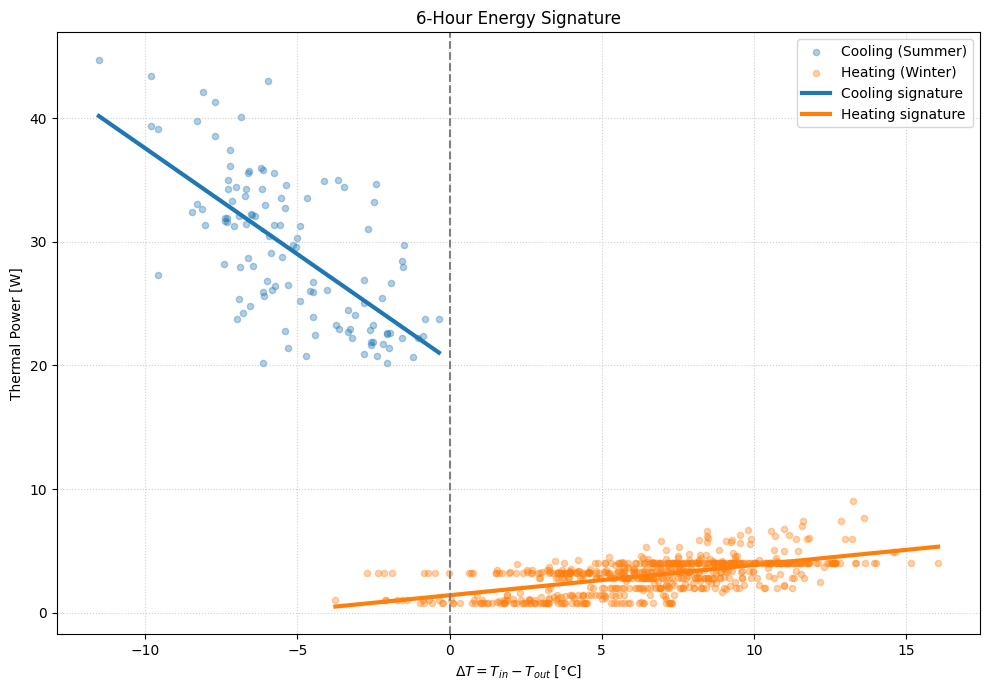

Signature metrics: {'k_heating': np.float64(0.2446010414222392), 'r2_heating': 0.36221603087252063, 'k_cooling': np.float64(-1.7123778041888897), 'r2_cooling': 0.446767182318623}
Preparing data with interval: 1d
Loading CSV files...
Loaded 1429 records
Date range: 2026-01-04 01:00:00 to 2026-12-27 01:00:00
Columns: ['time', 'simulation_observations.mean { name: DistrictCooling }', 'simulation_observations.mean { name: DistrictHeating }', 'simulation_observations.mean { name: Electricity }', 'simulation_observations.mean { name: Tin_Flat2_Zona1 }', 'simulation_observations.mean { name: Tin_Flat2_Zona2 }', 'simulation_observations.mean { name: Tin_Flat2_Zona3 }', 'simulation_observations.mean { name: Tin_Flat2_Zona4 }', 'simulation_observations.mean { name: Tout }', 'simulation_observations.mean { name: DNI }', 'simulation_actions.mean { name: A_Shade_Flat2_Z1_W2 }', 'simulation_actions.mean { name: A_Shade_Flat2_Z1_W8 }', 'simulation_actions.mean { name: A_Shade_Flat2_Z1_W9 }', 'simulat

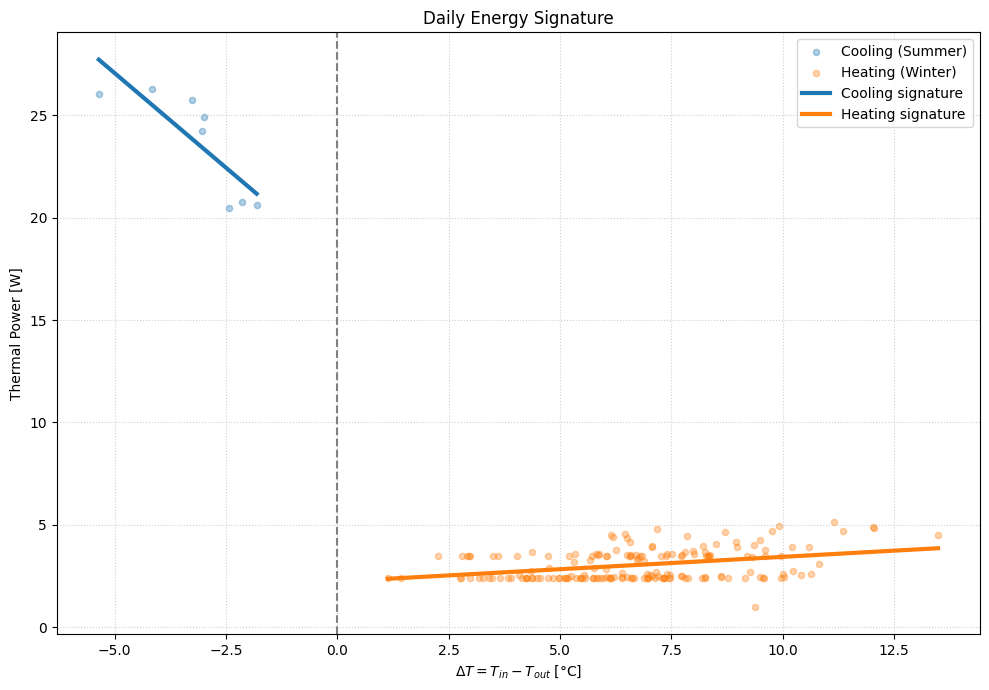

Signature metrics: {'k_heating': np.float64(0.12075621654500696), 'r2_heating': 0.12842498390169155, 'k_cooling': np.float64(-1.8479528165116936), 'r2_cooling': 0.6808795213272338}
Preparing data with interval: 7d
Loading CSV files...
Loaded 1429 records
Date range: 2026-01-04 01:00:00 to 2026-12-27 01:00:00
Columns: ['time', 'simulation_observations.mean { name: DistrictCooling }', 'simulation_observations.mean { name: DistrictHeating }', 'simulation_observations.mean { name: Electricity }', 'simulation_observations.mean { name: Tin_Flat2_Zona1 }', 'simulation_observations.mean { name: Tin_Flat2_Zona2 }', 'simulation_observations.mean { name: Tin_Flat2_Zona3 }', 'simulation_observations.mean { name: Tin_Flat2_Zona4 }', 'simulation_observations.mean { name: Tout }', 'simulation_observations.mean { name: DNI }', 'simulation_actions.mean { name: A_Shade_Flat2_Z1_W2 }', 'simulation_actions.mean { name: A_Shade_Flat2_Z1_W8 }', 'simulation_actions.mean { name: A_Shade_Flat2_Z1_W9 }', 'simul

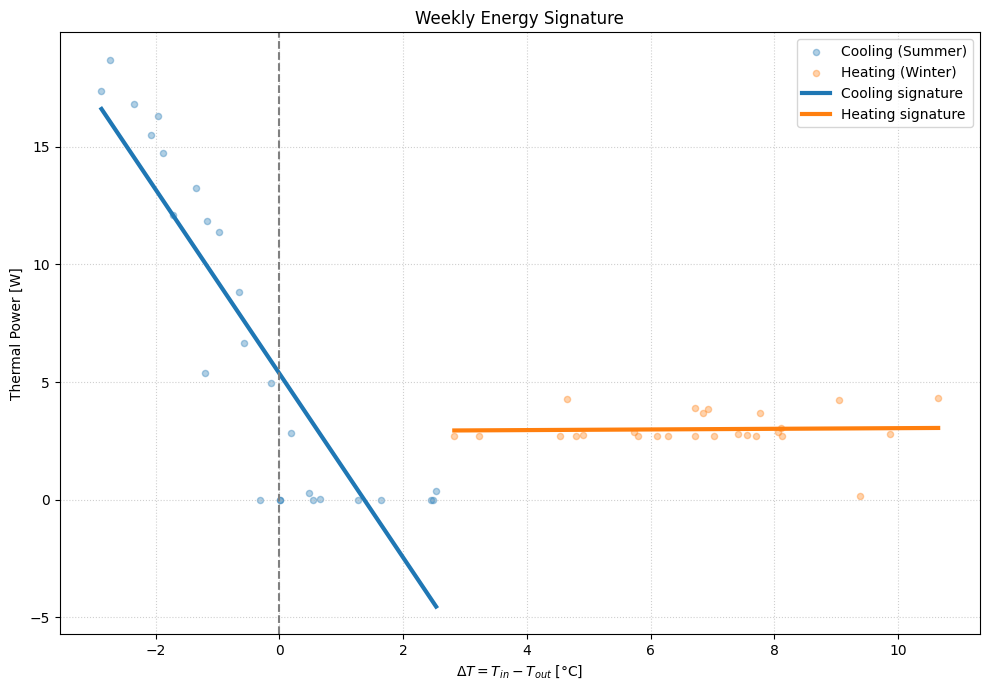

Signature metrics: {'k_heating': np.float64(0.013644703243589665), 'r2_heating': 0.0010410909301579174, 'k_cooling': np.float64(-3.9088762669544352), 'r2_cooling': 0.7835634939489081}
Preparing data with interval: 30d
Loading CSV files...
Loaded 1429 records
Date range: 2026-01-04 01:00:00 to 2026-12-27 01:00:00
Columns: ['time', 'simulation_observations.mean { name: DistrictCooling }', 'simulation_observations.mean { name: DistrictHeating }', 'simulation_observations.mean { name: Electricity }', 'simulation_observations.mean { name: Tin_Flat2_Zona1 }', 'simulation_observations.mean { name: Tin_Flat2_Zona2 }', 'simulation_observations.mean { name: Tin_Flat2_Zona3 }', 'simulation_observations.mean { name: Tin_Flat2_Zona4 }', 'simulation_observations.mean { name: Tout }', 'simulation_observations.mean { name: DNI }', 'simulation_actions.mean { name: A_Shade_Flat2_Z1_W2 }', 'simulation_actions.mean { name: A_Shade_Flat2_Z1_W8 }', 'simulation_actions.mean { name: A_Shade_Flat2_Z1_W9 }', 's

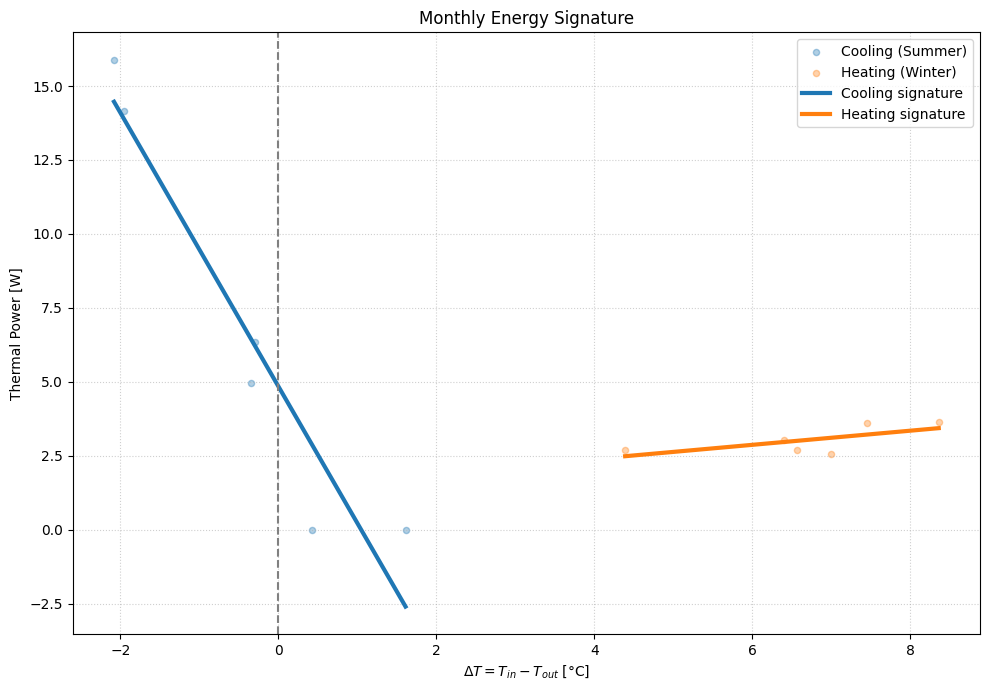

Signature metrics: {'k_heating': np.float64(0.23885000809431753), 'r2_heating': 0.45406441127726416, 'k_cooling': np.float64(-4.6219555993209855), 'r2_cooling': 0.9168596858593416}


In [30]:
def plot_energy_signature(group_by_time, title, threshold_cooling, threshold_heating):
    """
    Plot cooling/heating energy signatures for a chosen aggregation interval.
    """
    print(f"Preparing data with interval: {group_by_time}")
    dataset = load_from_csv(ENERGY_FILE, TEMPERATURE_FILE, DNI_FILE, SHADING_FILE)

    if dataset.empty:
        print("No data available.")
        return

    # Ensure datetime index
    dataset['time'] = pd.to_datetime(dataset['time'])
    dataset = dataset.sort_values('time').set_index('time')

    # Aggregate by requested interval (sum for energies, mean for temperatures/others)
    agg_dict = {}
    for col in dataset.columns:
        if col in ['DistrictHeating', 'DistrictCooling', 'Electricity'] or 'DistrictHeating' in col or 'DistrictCooling' in col or col == 'Electricity':
            agg_dict[col] = 'sum'
        elif col.startswith('Tair_') or col == 'T_ext' or col == 'DNI' or 'shade' in col.lower():
            agg_dict[col] = 'mean'
        else:
            agg_dict[col] = 'mean'

    df = dataset.resample(group_by_time).agg(agg_dict).dropna().reset_index()

    # Check required fields
    required = ['DistrictHeating', 'DistrictCooling', 'T_ext']
    missing = [c for c in required if c not in df.columns]
    if missing:
        print(f"Missing required columns after mapping: {missing}")
        return

    # Compute average indoor temperature from available zones
    t_zones = [c for c in ['Tair_z1', 'Tair_z2', 'Tair_z3', 'Tair_z4'] if c in df.columns]
    if not t_zones:
        print("No indoor zone temperature columns found (expected Tair_z1..Tair_z4).")
        return

    df['T_in_avg'] = df[t_zones].mean(axis=1)
    df['Delta_T'] = df['T_in_avg'] - df['T_ext']

    # Convert aggregated energy [kWh] to average thermal power [W]
    dt_seconds = pd.to_timedelta(group_by_time).total_seconds()
    df['QH'] = (df['DistrictHeating'].abs() * 3_600_000) / dt_seconds   # QH is the average heating power in W
    df['QC'] = (df['DistrictCooling'].abs() * 3_600_000) / dt_seconds   # QC is the average cooling power in W

    # Remove invalid rows
    df = df.dropna(subset=['Delta_T', 'QH', 'QC'])
    if df.empty:
        print("No valid rows after cleaning.")
        return

    # Heating season: Oct-Mar
    month = df['time'].dt.month
    is_heating_season = (month <= 3) | (month >= 10)

    df_winter_all = df[is_heating_season].copy()
    df_summer_all = df[~is_heating_season].copy()
    df_winter = df_winter_all.copy()
    df_summer = df_summer_all.copy()

    # Apply power thresholds (except monthly)
    if group_by_time != '30d':
        df_winter_thr = df_winter_all[df_winter_all['QH'] > threshold_heating]
        df_summer_thr = df_summer_all[df_summer_all['QC'] > threshold_cooling]

        # Fallback season-by-season if a threshold removes everything
        if df_winter_thr.empty and not df_winter_all.empty:
            print("Heating points removed by threshold -> using all heating points for this interval.")
            df_winter = df_winter_all
        else:
            df_winter = df_winter_thr

        if df_summer_thr.empty and not df_summer_all.empty:
            print("Cooling points removed by threshold -> using all cooling points for this interval.")
            df_summer = df_summer_all
        else:
            df_summer = df_summer_thr

    print(f"Winter points: {len(df_winter)} | Summer points: {len(df_summer)}")

    stats = {
        'k_heating': None, 'r2_heating': None,
        'k_cooling': None, 'r2_cooling': None
    }

    plt.figure(figsize=(10, 7))

    # Scatter points
    if not df_summer.empty:
        plt.scatter(
            df_summer['Delta_T'],
            df_summer['QC'],
            label='Cooling (Summer)',
            color='tab:blue',
            alpha=0.35,
            s=20
        )

    if not df_winter.empty:
        plt.scatter(
            df_winter['Delta_T'],
            df_winter['QH'],
            label='Heating (Winter)',
            color='tab:orange',
            alpha=0.35,
            s=20
        )

    # Regression lines
    if len(df_summer) > 1:
        z_c = np.polyfit(df_summer['Delta_T'], df_summer['QC'], 1)
        p_c = np.poly1d(z_c)
        x_c = np.sort(df_summer['Delta_T'])
        plt.plot(x_c, p_c(x_c), linewidth=3, label='Cooling signature', color='tab:blue')
        stats['k_cooling'] = z_c[0]
        stats['r2_cooling'] = r2_score(df_summer['QC'], p_c(df_summer['Delta_T']))

    if len(df_winter) > 1:
        z_h = np.polyfit(df_winter['Delta_T'], df_winter['QH'], 1)
        p_h = np.poly1d(z_h)
        x_h = np.sort(df_winter['Delta_T'])
        plt.plot(x_h, p_h(x_h), linewidth=3, label='Heating signature', color='tab:orange')
        stats['k_heating'] = z_h[0]
        stats['r2_heating'] = r2_score(df_winter['QH'], p_h(df_winter['Delta_T']))

    plt.title(title)
    plt.xlabel(r'$\Delta T = T_{in} - T_{out}$ [°C]')
    plt.ylabel('Thermal Power [W]')
    plt.axvline(x=0, color='gray', linestyle='--')
    plt.grid(True, linestyle=':', alpha=0.6)

    handles, labels = plt.gca().get_legend_handles_labels()
    if handles:
        plt.legend()

    plt.tight_layout()
    plt.show()

    print("Signature metrics:", stats)


# Plot the 6-hour energy signature (replaces hourly, since raw step is 6h)
group_time_6h = '6h'
title_6h = '6-Hour Energy Signature'
plot_energy_signature(group_time_6h, title_6h, THRESHOLD_COOLING, THRESHOLD_HEATING)

# Plot the daily energy signature
group_time_day = '1d'
title_day = 'Daily Energy Signature'
plot_energy_signature(group_time_day, title_day, THRESHOLD_COOLING, THRESHOLD_HEATING)

# Plot the weekly energy signature
group_time_week = '7d'
title_week = 'Weekly Energy Signature'
plot_energy_signature(group_time_week, title_week, THRESHOLD_COOLING, THRESHOLD_HEATING)

# Plot the monthly energy signature
group_time_month = '30d'
title_month = 'Monthly Energy Signature'
plot_energy_signature(group_time_month, title_month, THRESHOLD_COOLING, THRESHOLD_HEATING)